In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

In [2]:
df = pd.read_csv("clean_resume_dataset.csv")

In [3]:
df.head()

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source,Clean_Resume
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas,jessica claire montgomery street san francisco...
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas,jared arthur maica java developer linkedincomi...
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,jessica claire resumesampleexamplecom montgome...
3,REAL_0004,Java Developer,Christine Kelley,contact@email.com,9 555 4321000 94105 5 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,jessica claire resumesampleexamplecom montgome...
4,REAL_0005,Java Developer,Karen Holt,contact@email.com,100 10 4321000 ...,"City, State",jessica claire 100 montgomery st 10th floor xx...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...,Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas,jessica claire montgomery st th floor xxx resu...


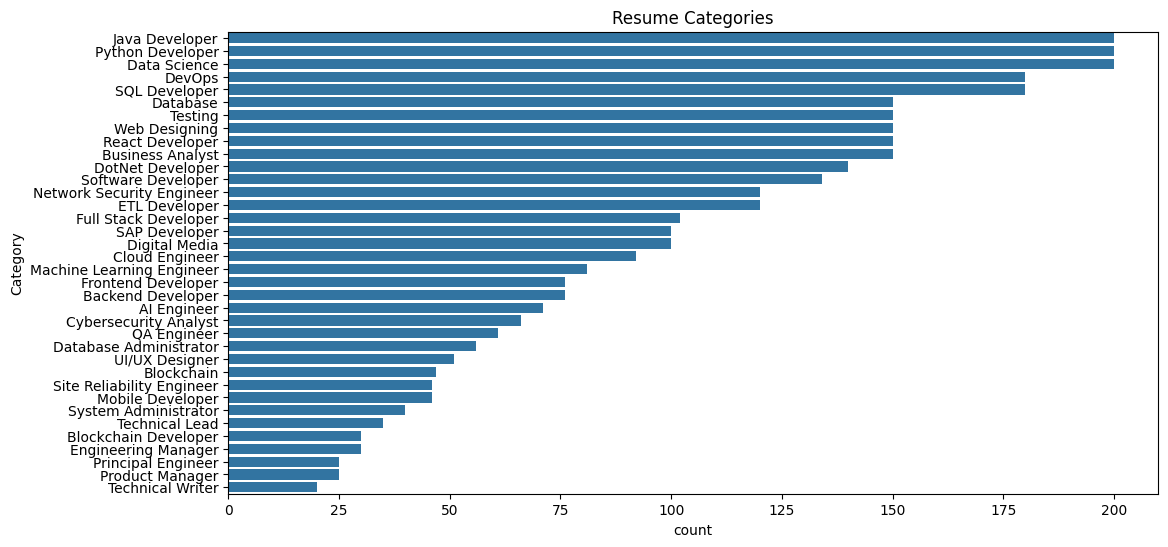

In [5]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df["Category"],
        order=df["Category"].value_counts().index)

plt.title("Resume Categories")
plt.show()

In [6]:
encoder = LabelEncoder()

df["Category"] = encoder.fit_transform(df["Category"])

In [7]:
df.head()

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source,Clean_Resume
0,REAL_0001,17,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas,jessica claire montgomery street san francisco...
1,REAL_0002,17,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas,jared arthur maica java developer linkedincomi...
2,REAL_0003,17,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,jessica claire resumesampleexamplecom montgome...
3,REAL_0004,17,Christine Kelley,contact@email.com,9 555 4321000 94105 5 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,jessica claire resumesampleexamplecom montgome...
4,REAL_0005,17,Karen Holt,contact@email.com,100 10 4321000 ...,"City, State",jessica claire 100 montgomery st 10th floor xx...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...,Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas,jessica claire montgomery st th floor xxx resu...


In [8]:
X = df["Clean_Resume"]

y = df["Category"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)



In [10]:
tfidf = TfidfVectorizer(stop_words="english",max_features=5000)


In [11]:
X_train = tfidf.fit_transform(X_train)

X_test = tfidf.transform(X_test)

In [12]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [13]:
prediction_lr = lr.predict(X_test)

In [14]:
print("Accuracy :",
      accuracy_score(y_test,prediction_lr))

Accuracy : 0.88


In [15]:
print(classification_report(y_test,prediction_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        17
           2       1.00      0.40      0.57         5
           3       1.00      1.00      1.00         5
           4       0.81      0.96      0.88        26
           5       1.00      1.00      1.00        13
           6       1.00      1.00      1.00        13
           7       0.81      0.92      0.86        50
           8       0.83      0.61      0.70        33
           9       1.00      1.00      1.00         9
          10       0.94      1.00      0.97        32
          11       0.80      0.80      0.80        20
          12       0.84      0.78      0.81        27
          13       0.93      0.90      0.92        31
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00        16
          16       1.00      1.00      1.00        18
          17       0.86    

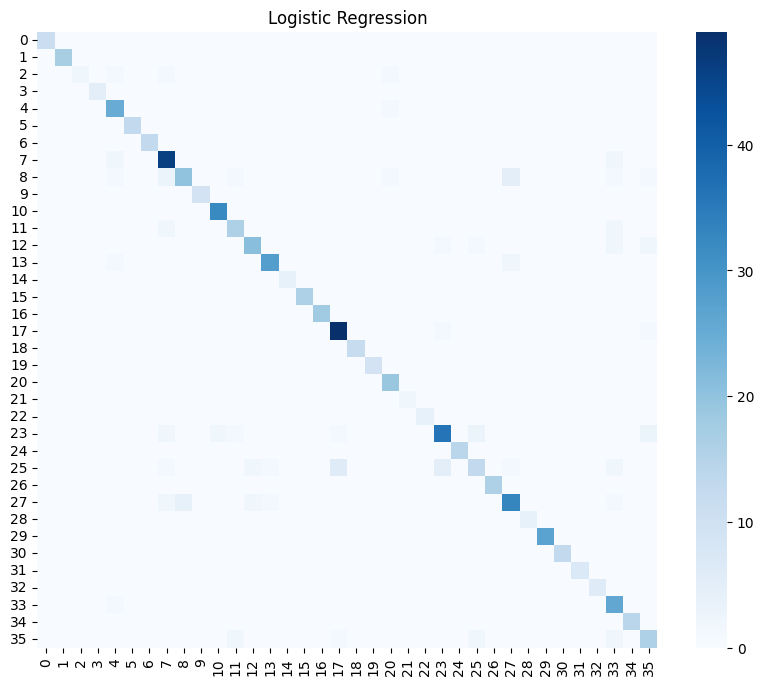

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(
    confusion_matrix(y_test,prediction_lr),
        cmap="Blues"
        )

plt.title("Logistic Regression")

plt.show()

In [18]:
svm = LinearSVC()

In [19]:
svm.fit(X_train,y_train)

LinearSVC()

In [20]:
prediction_svm = svm.predict(X_test)

In [21]:
print("Accuracy :",accuracy_score(y_test,prediction_svm))

Accuracy : 0.8814285714285715


In [22]:
print(classification_report(y_test,prediction_svm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        17
           2       1.00      0.80      0.89         5
           3       1.00      1.00      1.00         5
           4       0.83      0.96      0.89        26
           5       0.93      1.00      0.96        13
           6       1.00      1.00      1.00        13
           7       0.88      0.92      0.90        50
           8       0.79      0.58      0.67        33
           9       1.00      1.00      1.00         9
          10       0.97      1.00      0.98        32
          11       0.86      0.90      0.88        20
          12       0.85      0.85      0.85        27
          13       1.00      0.84      0.91        31
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00        16
          16       1.00      1.00      1.00        18
          17       0.89    

In [25]:
rf = RandomForestClassifier(n_estimators=200,random_state=42)


In [26]:
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [27]:
prediction_rf = rf.predict(X_test)

In [28]:
print("Accuracy :",accuracy_score(y_test,prediction_rf))

Accuracy : 0.8571428571428571


In [29]:
print(classification_report(y_test,prediction_rf))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        11
           1       1.00      1.00      1.00        17
           2       1.00      0.60      0.75         5
           3       1.00      1.00      1.00         5
           4       0.89      0.96      0.93        26
           5       1.00      1.00      1.00        13
           6       1.00      1.00      1.00        13
           7       0.85      0.90      0.87        50
           8       0.69      0.55      0.61        33
           9       1.00      1.00      1.00         9
          10       0.86      1.00      0.93        32
          11       0.85      0.85      0.85        20
          12       0.79      0.81      0.80        27
          13       0.96      0.77      0.86        31
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00        16
          16       1.00      1.00      1.00        18
          17       0.81    

In [30]:
lr_acc = accuracy_score(y_test,prediction_lr)

svm_acc = accuracy_score(y_test,prediction_svm)

rf_acc = accuracy_score(y_test,prediction_rf)

In [34]:
comparison = pd.DataFrame({

      "Model":[
              "Logistic Regression",
              "Linear SVM",
              "Random Forest"
              ],

              "Accuracy":[
                           lr_acc,
                           svm_acc,
                           rf_acc
                         ]
})

comparison


,Model,Accuracy
0,Logistic Regression,0.880000
1,Linear SVM,0.881429
2,Random Forest,0.857143


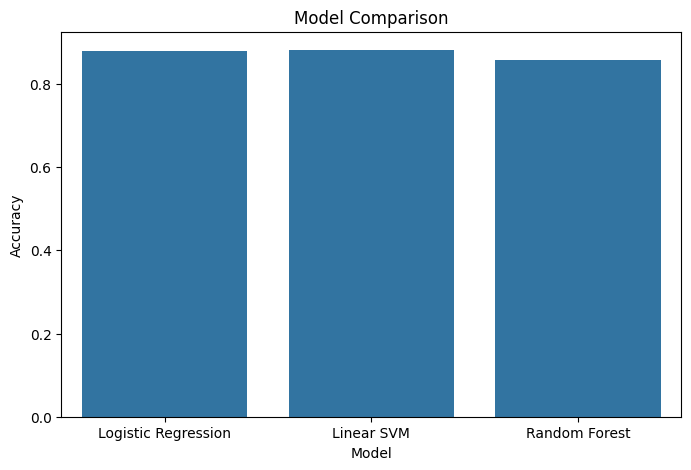

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
        y="Accuracy",
            data=comparison
            )

plt.title("Model Comparison")
plt.show()

In [36]:
joblib.dump(svm,"resume_classifier.pkl")

joblib.dump(tfidf,"tfidf.pkl")

joblib.dump(encoder,"label_encoder.pkl")

['label_encoder.pkl']

In [37]:
print("Models Saved Successfully")

Models Saved Successfully


In [38]:
resume = """
Python Developer

Machine Learning

Deep Learning

SQL

Pandas

TensorFlow

Scikit Learn

Data Analysis
"""

In [39]:
resume = tfidf.transform([resume])

prediction = svm.predict(resume)

category = encoder.inverse_transform(prediction)

print(category[0])

Machine Learning Engineer
